# Phase 2 Gradient Dynamics 분석 노트북: v3 결과

이 노트북은 `gradient_analysis_results` 의 **v3** 산출물을 분석합니다.

- **HiP-AD:** `gradient_analysis_results/v3` — checkpoint `1ep / 3ep / 6ep / 18ep`
- **VAD:** `gradient_analysis_results/vad_bev_shared_v3` — checkpoint `ep1 / ep30 / ep60`

기존 `phase2_hipad_vad_analysis_visualization.ipynb` 의 코어 진단(conflict / null-baseline /
distribution / layer-correlation / 1-step probe)을 v3 데이터로 재현하고, epoch dynamics 시계열,
그리고 **v3 에서 새로 추가된 query sensitivity**(`v3/.../query_sensitivity/`) 분석을 더합니다.

핵심 질문:

1. v3 에서 multi-task gradient conflict 가 실제로 강하게 나타나는가?
2. conflict 가 있다면 어느 task pair / 어느 group(layer 묶음)에서 생기는가?
3. 1-step probe 에서 각 task 의 gradient step 이 다른 task loss 에 도움인가 해인가?
4. epoch 이 진행되며 conflict / helpful 신호가 어떻게 변하는가?
5. planning loss 의 gradient 가 어느 task 의 query 까지 도달하는가? (query sensitivity, v3 신규)


## 0. 개념 정리

- **task**: `det`, `map`, `motion`, `plan` 네 가지.
- **gradient cosine**: 두 task gradient 방향의 유사도. `>0` 협력, `<0` 충돌, `≈0` 직교/약신호.
- **conflict_ratio**: batch 중 cosine 이 음수인 비율. 0.5 면 random, 0.6+ 면 자주 충돌.
  단, mean cosine 이 거의 0 이면 부호가 자주 음수여도 효과 크기는 작다.
- **null-baseline pass rate**: 관측 cosine 이 permutation/sign-flip null 과 구분되는 셀 비율.
  Phase 1 에서 30% 를 direction-conflict signal 의 기준으로 썼다.
- **1-step probe**: source task gradient 방향으로 파라미터를 조금 움직인 뒤 target loss 변화(`delta`).
  `delta < 0` → target loss 감소 → **도움(helpful)**, `delta > 0` → **해(harmful)**.
- **pseudo-shared group**: 한 task gradient 가 EPS 미만인 batch 가 절반 이상인 group.
  cosine 해석이 불가능해 메인 분석에서 제외한다 (`is_pseudo_shared_group=True`).
- 그림 텍스트는 영어(한글 폰트 의존성 회피), 본문 해석은 한국어.


## 1. 데이터 로딩

원본 실험을 다시 돌리지 않고, 이미 생성된 CSV 산출물만 읽어 표/그림을 만듭니다.
사용하는 주요 산출물:

- `conflict/conflict_*_summary.csv` — 기본 shared group 기준 conflict
- `layer_conflict/conflict_*_summary.csv` — layer group 별 conflict
- `null_baseline/null_baseline.csv` — permutation / sign-flip null 검정
- `distribution/distribution_report.csv` — cosine 분포 형태
- `layer_correlation/layer_correlation_table.csv` — cosine 과 1-step loss 변화의 상관
- `probe/probe_per_batch.csv` — 1-step probe 의 source→target delta
- `dynamics/cos_dynamics.csv`, `dynamics/helpful_dynamics.csv` — v3 신규: epoch 시계열


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

warnings.filterwarnings('ignore')

REPO_ROOT = Path('/home/yongjae/e2e/HiP-AD-pcgrad')
RESULTS_ROOT = REPO_ROOT / 'gradient_analysis_results'

_CANDIDATE_RUNS = {
    'HiP-AD': RESULTS_ROOT / 'v3',
    'VAD':    RESULTS_ROOT / 'vad_bev_shared_v3',
}

RUNS = {}
for _name, _path in _CANDIDATE_RUNS.items():
    if _path.exists():
        RUNS[_name] = _path
    else:
        warnings.warn(f'[skip] run root missing for {_name}: {_path}')

print('Active runs:')
for _name, _path in RUNS.items():
    print(f'  {_name}: {_path}')

TASKS = ['det', 'map', 'motion', 'plan']
TASK_PAIRS = [('det', 'map'), ('det', 'motion'), ('det', 'plan'),
              ('map', 'motion'), ('map', 'plan'), ('motion', 'plan')]
TASK_PAIR_LABELS = [f'{a}-{b}' for a, b in TASK_PAIRS]

plt.rcParams.update({
    'figure.figsize': (10, 5),
    'axes.grid': True,
    'grid.alpha': 0.25,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})


def checkpoint_sort_key(tag: str):
    digits = ''.join(ch for ch in tag if ch.isdigit())
    return int(digits) if digits else 0


def checkpoint_dirs(run_root: Path):
    dirs = [p for p in run_root.glob('ckpt_*') if p.is_dir()]
    return sorted(dirs, key=lambda p: checkpoint_sort_key(p.name.replace('ckpt_', '')))


def checkpoint_tag(path: Path):
    return path.name.replace('ckpt_', '')


def add_model_and_checkpoint(df: pd.DataFrame, model: str, ckpt_dir: Path):
    df = df.copy()
    df['model'] = model
    df['checkpoint'] = checkpoint_tag(ckpt_dir)
    df['checkpoint_order'] = checkpoint_sort_key(checkpoint_tag(ckpt_dir))
    return df

Active runs:
  HiP-AD: /home/yongjae/e2e/HiP-AD-pcgrad/gradient_analysis_results/v3
  VAD: /home/yongjae/e2e/HiP-AD-pcgrad/gradient_analysis_results/vad_bev_shared_v3


In [2]:
def _load_per_ckpt(rel_glob, single=False):
    """rel_glob: glob pattern relative to a ckpt dir. single=True -> one fixed file."""
    frames = []
    for model, root in RUNS.items():
        for ckpt in checkpoint_dirs(root):
            if single:
                paths = [ckpt / rel_glob] if (ckpt / rel_glob).exists() else []
            else:
                paths = sorted(ckpt.glob(rel_glob))
            if not paths:
                warnings.warn(f'[skip] {model} {ckpt.name}/{rel_glob} missing')
                continue
            for p in paths:
                try:
                    df = pd.read_csv(p)
                except (pd.errors.EmptyDataError, pd.errors.ParserError):
                    warnings.warn(f'[skip] {model} {ckpt.name}/{p.name} empty/unparseable')
                    continue
                if df.empty:
                    continue
                frames.append(add_model_and_checkpoint(df, model, ckpt))
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


def real_rows(df):
    """Drop pseudo-shared groups whose cosine is not interpretable."""
    if df.empty or 'is_pseudo_shared_group' not in df.columns:
        return df.copy()
    return df[~df['is_pseudo_shared_group'].fillna(False)].copy()


base_conflict   = _load_per_ckpt('conflict/conflict_*_summary.csv')
layer_conflict  = _load_per_ckpt('layer_conflict/conflict_*_summary.csv')
null_baseline   = _load_per_ckpt('null_baseline/null_baseline.csv', single=True)
distribution    = _load_per_ckpt('distribution/distribution_report.csv', single=True)
correlation     = _load_per_ckpt('layer_correlation/layer_correlation_table.csv', single=True)
probe           = _load_per_ckpt('probe/probe_per_batch.csv', single=True)

real_base_conflict  = real_rows(base_conflict)
real_layer_conflict = real_rows(layer_conflict)

print('Loaded rows')
for name, df in [('base_conflict', base_conflict), ('layer_conflict', layer_conflict),
                 ('null_baseline', null_baseline), ('distribution', distribution),
                 ('correlation', correlation), ('probe', probe)]:
    n = len(df)
    models = sorted(df['model'].unique()) if n else []
    print(f'  {name:16s}: {n:7d} rows  models={models}')

Loaded rows
  base_conflict   :     360 rows  models=['HiP-AD', 'VAD']
  layer_conflict  :     612 rows  models=['HiP-AD', 'VAD']
  null_baseline   :     720 rows  models=['HiP-AD', 'VAD']
  distribution    :     360 rows  models=['HiP-AD', 'VAD']
  correlation     :    1728 rows  models=['HiP-AD']
  probe           :  288000 rows  models=['HiP-AD', 'VAD']


## 2. Conflict 개요

`conflict/` 는 기본 shared group(`neck`, `fc_before`, `fc_after`) 기준,
`layer_conflict/` 는 더 잘게 나눈 layer group 기준입니다.
pseudo-shared group 은 제외하고 **real group** 만 봅니다.

`conflict_ratio` 가 0.5 근처면 random, 0.6 이상이면 자주 충돌 방향입니다.
다만 `mean_cos` 가 거의 0 이면 효과 크기는 작다는 점을 항상 같이 봐야 합니다.


In [3]:
def conflict_overview(df, title):
    if df.empty:
        print(f'[{title}] empty'); return
    g = (df.groupby(['model', 'checkpoint', 'checkpoint_order'])
           .agg(mean_conflict_ratio=('conflict_ratio', 'mean'),
                mean_cos=('mean_cos', 'mean'),
                n_cells=('conflict_ratio', 'size'))
           .reset_index()
           .sort_values(['model', 'checkpoint_order']))
    print(f'=== {title} : per-checkpoint summary (real groups) ===')
    display(g.drop(columns='checkpoint_order'))


conflict_overview(real_base_conflict, 'base conflict')
conflict_overview(real_layer_conflict, 'layer conflict')

=== base conflict : per-checkpoint summary (real groups) ===


,model,checkpoint,mean_conflict_ratio,mean_cos,n_cells
1,HiP-AD,1ep,0.427500,0.027691,12
2,HiP-AD,3ep,0.433333,0.024050,12
3,HiP-AD,6ep,0.421667,0.021138,12
0,HiP-AD,18ep,0.410000,0.029411,12
4,VAD,ep1,0.413500,0.039952,60
5,VAD,ep30,0.382632,0.060862,114
6,VAD,ep60,0.417982,0.047089,114


=== layer conflict : per-checkpoint summary (real groups) ===


,model,checkpoint,mean_conflict_ratio,mean_cos,n_cells
1,HiP-AD,1ep,0.465833,0.010470,108
2,HiP-AD,3ep,0.462037,0.011879,108
3,HiP-AD,6ep,0.474167,0.007238,108
0,HiP-AD,18ep,0.463056,0.013058,108
4,VAD,ep1,0.413500,0.039952,60
5,VAD,ep30,0.377667,0.050528,60
6,VAD,ep60,0.409333,0.039395,60


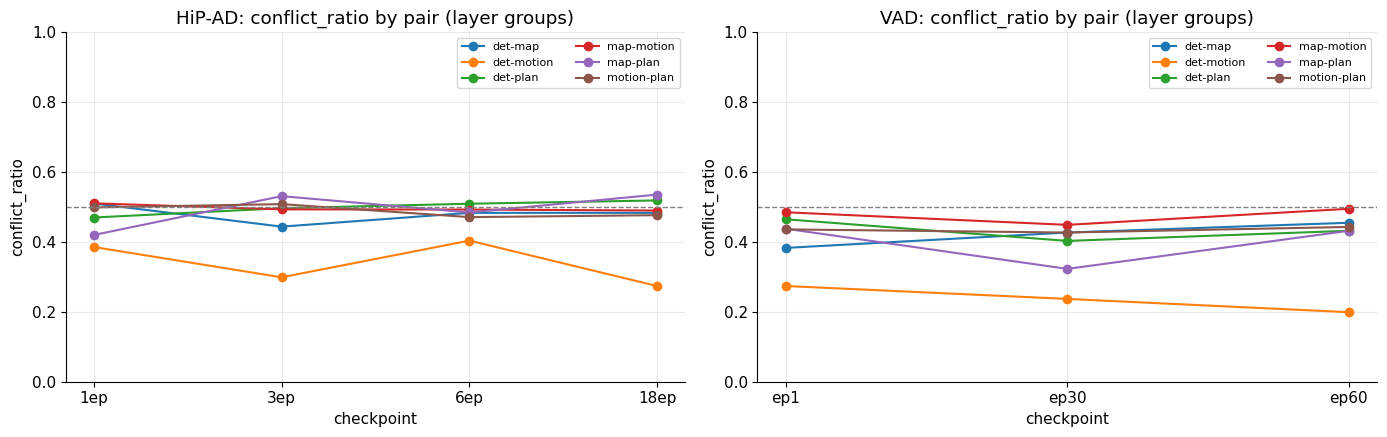

In [4]:
# conflict_ratio by task pair across checkpoints
def plot_conflict_ratio(df, title):
    if df.empty:
        print(f'[{title}] empty'); return
    df = df.copy()
    df['pair'] = df['task_a'] + '-' + df['task_b']
    models = sorted(df['model'].unique())
    fig, axes = plt.subplots(1, len(models), figsize=(7 * len(models), 4.5), squeeze=False)
    for ax, model in zip(axes[0], models):
        sub = df[df['model'] == model]
        order = sub.drop_duplicates('checkpoint').sort_values('checkpoint_order')['checkpoint']
        for pair, pdf in sub.groupby('pair'):
            pdf = (pdf.groupby(['checkpoint', 'checkpoint_order'])['conflict_ratio']
                      .mean().reset_index().sort_values('checkpoint_order'))
            ax.plot(pdf['checkpoint'], pdf['conflict_ratio'], marker='o', label=pair)
        ax.axhline(0.5, color='gray', ls='--', lw=1)
        ax.set_title(f'{model}: conflict_ratio by pair ({title})')
        ax.set_xlabel('checkpoint'); ax.set_ylabel('conflict_ratio')
        ax.set_ylim(0, 1); ax.legend(fontsize=8, ncol=2)
    plt.tight_layout(); plt.show()


plot_conflict_ratio(real_layer_conflict, 'layer groups')

In [5]:
# Highest / lowest conflict cells (real groups, layer level)
if not real_layer_conflict.empty:
    cols = ['model', 'checkpoint', 'task_a', 'task_b', 'group',
            'conflict_ratio', 'mean_cos', 'n_valid']
    show = real_layer_conflict[cols].copy()
    print('=== Highest conflict_ratio (real layer groups) ===')
    display(show.sort_values('conflict_ratio', ascending=False).head(10).reset_index(drop=True))
    print('=== Lowest conflict_ratio (real layer groups) ===')
    display(show.sort_values('conflict_ratio').head(10).reset_index(drop=True))

=== Highest conflict_ratio (real layer groups) ===


,model,checkpoint,task_a,task_b,group,conflict_ratio,mean_cos,n_valid
0,HiP-AD,1ep,det,map,dec4_ffn_0_pre_norm,0.68,-0.026229,100
1,HiP-AD,1ep,det,map,dec4_norm_0,0.65,-0.023475,100
2,HiP-AD,1ep,det,plan,dec5_norm_0,0.64,-0.016737,100
3,VAD,ep1,det,plan,enc0_temporal_self_attention,0.62,-0.017980,100
4,VAD,ep1,map,motion,enc0_ffn,0.62,-0.032317,100
5,HiP-AD,18ep,map,plan,dec5_norm_0,0.62,-0.012717,100
6,HiP-AD,3ep,map,plan,dec1_norm_0,0.62,-0.011388,100
7,HiP-AD,18ep,map,plan,dec3_norm_0,0.62,-0.016551,100
8,HiP-AD,1ep,det,map,dec4_norm_1,0.62,-0.019577,100
9,HiP-AD,1ep,map,motion,dec4_norm_1,0.62,-0.006487,100


=== Lowest conflict_ratio (real layer groups) ===


,model,checkpoint,task_a,task_b,group,conflict_ratio,mean_cos,n_valid
0,VAD,ep60,det,motion,bev_embedding,0.09,0.176003,100
1,VAD,ep30,map,plan,enc2_spatial_cross_attention,0.11,0.149664,100
2,VAD,ep60,det,motion,enc1_temporal_self_attention,0.13,0.202287,100
3,VAD,ep30,map,plan,enc1_ffn,0.13,0.144169,100
4,VAD,ep30,map,plan,enc2_temporal_self_attention,0.15,0.072957,100
5,VAD,ep30,det,motion,enc0_temporal_self_attention,0.15,0.194456,100
6,VAD,ep30,det,motion,bev_embedding,0.15,0.133817,100
7,VAD,ep30,det,motion,enc1_temporal_self_attention,0.15,0.175876,100
8,VAD,ep60,det,motion,enc2_temporal_self_attention,0.16,0.161864,100
9,VAD,ep1,det,motion,bev_embedding,0.17,0.138897,100


**해석 포인트**

- conflict_ratio 가 0.5 를 의미 있게 넘는 pair/group 이 direction surgery(PCGrad 류) 의 후보입니다.
- 가장 충돌이 큰 셀이라도 `mean_cos` 가 -0.01 수준이면, 부호는 음수여도 평균 효과 크기는 작습니다.
  → 다음 절의 null-baseline 으로 "noise 와 구분되는가" 를 확인해야 합니다.


## 3. Null-baseline pass rate

관측 cosine 이 permutation/sign-flip null 과 구분되는지 검정합니다.
`passes_noise_threshold=True` 인 셀 비율이 pass rate 입니다.
Phase 1 기준 30% 를 direction-conflict signal 의 임계로 사용했습니다.


=== Null-baseline pass rate (fraction of cells passing) ===


null_kind,model,checkpoint,batch_permutation,sign_flip
1,HiP-AD,1ep,0.166667,0.277778
2,HiP-AD,3ep,0.222222,0.222222
3,HiP-AD,6ep,0.222222,0.333333
0,HiP-AD,18ep,0.166667,0.166667
4,VAD,ep1,0.166667,0.366667
5,VAD,ep30,0.087719,0.508772
6,VAD,ep60,0.157895,0.333333


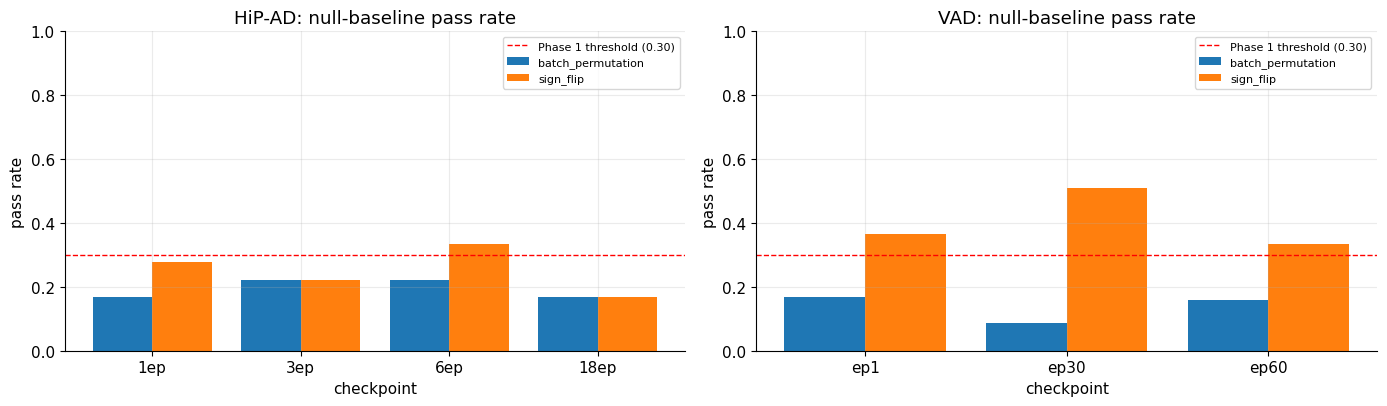

In [6]:
if not null_baseline.empty:
    nb = null_baseline.copy()
    pass_rate = (nb.groupby(['model', 'checkpoint', 'checkpoint_order', 'null_kind'])
                   ['passes_noise_threshold'].mean().reset_index()
                   .sort_values(['model', 'checkpoint_order']))
    pivot = pass_rate.pivot_table(index=['model', 'checkpoint', 'checkpoint_order'],
                                  columns='null_kind', values='passes_noise_threshold')
    pivot = pivot.reset_index().sort_values(['model', 'checkpoint_order'])
    print('=== Null-baseline pass rate (fraction of cells passing) ===')
    display(pivot.drop(columns='checkpoint_order'))

    kinds = sorted(nb['null_kind'].unique())
    models = sorted(nb['model'].unique())
    fig, axes = plt.subplots(1, len(models), figsize=(7 * len(models), 4.2), squeeze=False)
    for ax, model in zip(axes[0], models):
        sub = pass_rate[pass_rate['model'] == model]
        order = sub.drop_duplicates('checkpoint').sort_values('checkpoint_order')['checkpoint'].tolist()
        x = np.arange(len(order)); w = 0.8 / max(len(kinds), 1)
        for i, k in enumerate(kinds):
            ks = sub[sub['null_kind'] == k].set_index('checkpoint').reindex(order)
            ax.bar(x + i * w, ks['passes_noise_threshold'].values, w, label=k)
        ax.axhline(0.30, color='red', ls='--', lw=1, label='Phase 1 threshold (0.30)')
        ax.set_xticks(x + w * (len(kinds) - 1) / 2); ax.set_xticklabels(order)
        ax.set_title(f'{model}: null-baseline pass rate'); ax.set_ylim(0, 1)
        ax.set_xlabel('checkpoint'); ax.set_ylabel('pass rate'); ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()
else:
    print('null_baseline empty')

**해석 포인트**

- pass rate 가 30% 선 아래에 머물면, conflict_ratio 가 0.6 이어도 그 신호는 대체로 noise 와
  구분되지 않습니다 → direction surgery 의 근거가 약함.
- `sign_flip` 은 평균이 0 과 다른지에 가깝고, `batch_permutation` 은 batch 구조까지 섞는 더
  보수적인 기준입니다. 두 기준의 차이가 크면 신호가 batch 구조에 의존한다는 뜻입니다.


## 4. Cosine 분포 형태 (distribution)

`distribution_report.csv` 는 group/pair 별 cosine 분포의 모양(`shape_label`)을 분류합니다.
`bimodal` 이면 평균이 분포를 대표하지 못하므로(`mean_is_misleading`) 모드를 따로 봐야 합니다.


In [7]:
if not distribution.empty:
    dist = distribution.copy()
    census = (dist.groupby(['model', 'checkpoint', 'checkpoint_order', 'shape_label'])
                  .size().reset_index(name='count'))
    pivot = census.pivot_table(index=['model', 'checkpoint', 'checkpoint_order'],
                               columns='shape_label', values='count', fill_value=0)
    pivot = pivot.reset_index().sort_values(['model', 'checkpoint_order'])
    print('=== Distribution shape census (per checkpoint) ===')
    display(pivot.drop(columns='checkpoint_order'))

    bimodal = dist[dist['shape_label'] == 'bimodal']
    if not bimodal.empty:
        print('=== Bimodal cells (mean is misleading) ===')
        bcols = [c for c in ['model', 'checkpoint', 'task_a', 'task_b', 'group',
                             'dip_p_value', 'p5', 'p50', 'p95'] if c in bimodal.columns]
        display(bimodal[bcols].reset_index(drop=True))
    else:
        print('No bimodal cells.')
else:
    print('distribution empty')

=== Distribution shape census (per checkpoint) ===


shape_label,model,checkpoint,bimodal,empty,heavy-tail,unimodal-near-0,unimodal-neg,unimodal-pos
1,HiP-AD,1ep,1,6,0,8,0,3
2,HiP-AD,3ep,0,6,0,9,0,3
3,HiP-AD,6ep,5,6,0,7,0,0
0,HiP-AD,18ep,0,6,0,9,0,3
4,VAD,ep1,9,0,3,33,0,15
5,VAD,ep30,9,0,7,44,0,54
6,VAD,ep60,9,0,6,59,5,35


=== Bimodal cells (mean is misleading) ===


,model,checkpoint,task_a,task_b,group,dip_p_value,p5,p50,p95
0,HiP-AD,1ep,det,map,neck,0.01,-0.057422,-0.010694,0.070356
1,HiP-AD,6ep,det,motion,neck,0.01,-0.198216,0.104602,0.431103
2,HiP-AD,6ep,det,motion,fc_before,0.01,-0.154662,0.047498,0.286078
3,HiP-AD,6ep,det,motion,fc_after,0.01,-0.067377,0.051165,0.226333
4,HiP-AD,6ep,det,plan,fc_after,0.01,-0.078191,-0.000308,0.082693
5,HiP-AD,6ep,map,motion,neck,0.01,-0.062663,0.010020,0.054156
6,VAD,ep1,det,map,bev_embedding,0.01,-0.006533,0.002189,0.012762
7,VAD,ep1,det,map,enc0_temporal_self_attention,0.01,-0.050924,0.003267,0.083884
8,VAD,ep1,det,motion,enc2_ffn,0.01,-0.055771,0.063726,0.217304
9,VAD,ep1,det,plan,bev_embedding,0.01,-0.016798,-0.000359,0.016035


## 5. Layer correlation: cosine vs 1-step loss 변화

`layer_correlation_table.csv` 는 각 (source→target, layer) 셀에서 gradient cosine 과
1-step `delta` 의 상관(`pearson`)을 잽니다.

- cosine 이 PCGrad-류 분석의 가정대로 loss 변화를 잘 예측하면 `|pearson|` 이 큽니다.
- `mean_delta < 0` 이면 그 source step 이 평균적으로 target loss 를 줄였다는 뜻(도움).


=== cosine vs delta correlation (by self/cross) ===


,model,checkpoint,variant,kind,mean_pearson,mean_abs_pearson,mean_delta,n
2,HiP-AD,1ep,normalized,cross,-0.057136,0.099854,-0.000004,216
3,HiP-AD,1ep,raw,cross,-0.014297,0.082343,-0.000005,216
4,HiP-AD,3ep,normalized,cross,-0.035964,0.093201,0.000007,216
5,HiP-AD,3ep,raw,cross,0.000958,0.082819,0.000010,216
6,HiP-AD,6ep,normalized,cross,-0.012642,0.072034,0.000014,216
7,HiP-AD,6ep,raw,cross,0.010135,0.072535,0.000018,216
0,HiP-AD,18ep,normalized,cross,-0.003282,0.085296,0.000001,216
1,HiP-AD,18ep,raw,cross,0.014632,0.082856,0.000001,216


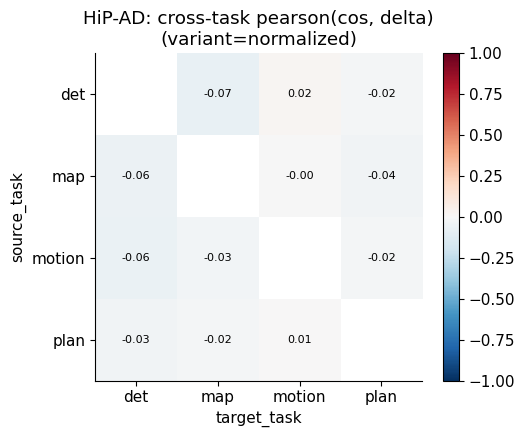

In [8]:
if not correlation.empty:
    corr = correlation.copy()
    # 같은 task끼리(self)와 cross를 구분
    corr['kind'] = np.where(corr['source_task'] == corr['target_task'], 'self', 'cross')
    summ = (corr.groupby(['model', 'checkpoint', 'checkpoint_order', 'variant', 'kind'])
                .agg(mean_pearson=('pearson', 'mean'),
                     mean_abs_pearson=('pearson', lambda s: s.abs().mean()),
                     mean_delta=('mean_delta', 'mean'),
                     n=('pearson', 'size'))
                .reset_index().sort_values(['model', 'checkpoint_order', 'variant', 'kind']))
    print('=== cosine vs delta correlation (by self/cross) ===')
    display(summ.drop(columns='checkpoint_order'))

    # cross-task pearson heatmap per model (variant=normalized if present else first)
    variant = 'normalized' if (corr['variant'] == 'normalized').any() else corr['variant'].iloc[0]
    cross = corr[(corr['kind'] == 'cross') & (corr['variant'] == variant)]
    models = sorted(cross['model'].unique())
    if models:
        fig, axes = plt.subplots(1, len(models), figsize=(6 * len(models), 4.5), squeeze=False)
        for ax, model in zip(axes[0], models):
            sub = cross[cross['model'] == model]
            mat = sub.pivot_table(index='source_task', columns='target_task',
                                  values='pearson', aggfunc='mean')
            im = ax.imshow(mat.values, cmap='RdBu_r', vmin=-1, vmax=1)
            ax.set_xticks(range(len(mat.columns))); ax.set_xticklabels(mat.columns)
            ax.set_yticks(range(len(mat.index))); ax.set_yticklabels(mat.index)
            ax.set_title(f'{model}: cross-task pearson(cos, delta)\n(variant={variant})')
            ax.set_xlabel('target_task'); ax.set_ylabel('source_task'); ax.grid(False)
            for i in range(len(mat.index)):
                for j in range(len(mat.columns)):
                    v = mat.values[i, j]
                    if not np.isnan(v):
                        ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=8)
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        plt.tight_layout(); plt.show()
else:
    print('correlation empty')

## 6. 1-step probe: source → target transfer

`probe_per_batch.csv` 는 source task gradient 로 1-step 움직인 뒤 target loss 변화 `delta` 입니다.

- 대각선(`source == target`): 자기 step 으로 자기 loss 가 줄어야 정상(`delta < 0`).
- 비대각: cross-task transfer/interference. `delta < 0` 도움, `delta > 0` 해.
- `helpful_rate = P(delta < 0)` 가 0.5 보다 의미 있게 커야 transfer 신호로 봅니다.


=== 1-step probe summary (variant=normalized, steps=1) ===


,model,source_task,target_task,mean_delta,median_delta,helpful_rate,n
0,HiP-AD,det,det,-0.000105,-6.580353e-05,0.966250,7200
1,HiP-AD,det,map,0.000001,-4.768372e-07,0.506389,7200
2,HiP-AD,det,motion,-0.000003,5.066395e-07,0.496667,7200
3,HiP-AD,det,plan,0.000003,8.940697e-07,0.490556,7200
4,HiP-AD,map,det,0.000017,0.000000e+00,0.484306,7200
5,HiP-AD,map,map,-0.000068,-5.149841e-05,0.881111,7200
6,HiP-AD,map,motion,0.000008,1.341105e-06,0.489028,7200
7,HiP-AD,map,plan,0.000005,1.668930e-06,0.481667,7200
8,HiP-AD,motion,det,0.000003,-3.814697e-06,0.577361,7200
9,HiP-AD,motion,map,0.000003,-4.768372e-07,0.504444,7200


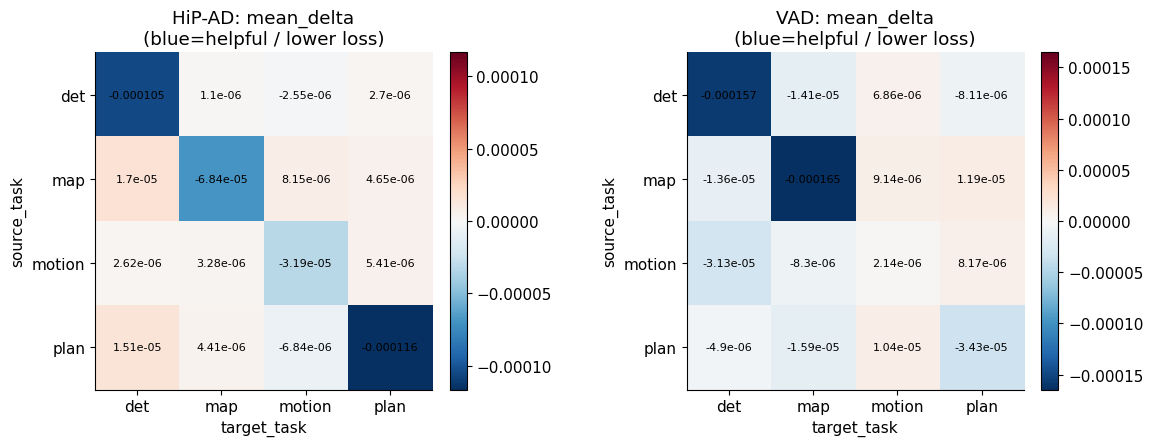

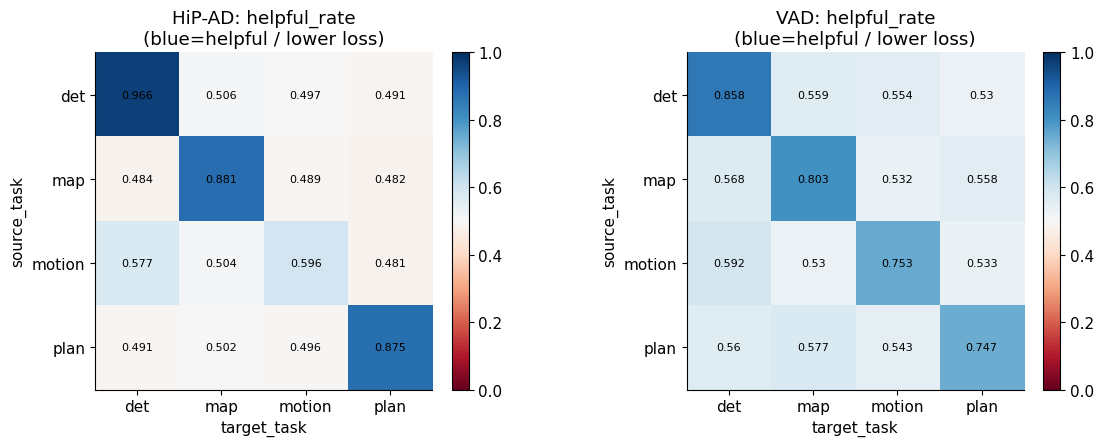

In [9]:
if not probe.empty:
    pr = probe.copy()
    # variant: normalized 우선, steps==1
    variant = 'normalized' if (pr['variant'] == 'normalized').any() else pr['variant'].iloc[0]
    pr = pr[(pr['variant'] == variant) & (pr['steps'] == 1)]
    cell = (pr.groupby(['model', 'source_task', 'target_task'])
              .agg(mean_delta=('delta', 'mean'),
                   median_delta=('delta', 'median'),
                   helpful_rate=('delta', lambda s: (s < 0).mean()),
                   n=('delta', 'size'))
              .reset_index())
    print(f'=== 1-step probe summary (variant={variant}, steps=1) ===')
    display(cell.sort_values(['model', 'source_task', 'target_task']).reset_index(drop=True))

    models = sorted(cell['model'].unique())
    for metric, cmap, center in [('mean_delta', 'RdBu_r', True),
                                 ('helpful_rate', 'RdBu', False)]:
        fig, axes = plt.subplots(1, len(models), figsize=(6 * len(models), 4.6), squeeze=False)
        for ax, model in zip(axes[0], models):
            sub = cell[cell['model'] == model]
            mat = sub.pivot_table(index='source_task', columns='target_task', values=metric)
            mat = mat.reindex(index=TASKS, columns=TASKS)
            if metric == 'mean_delta':
                vmax = np.nanmax(np.abs(mat.values)); vmin = -vmax
            else:
                vmin, vmax = 0.0, 1.0
            im = ax.imshow(mat.values, cmap=cmap, vmin=vmin, vmax=vmax)
            ax.set_xticks(range(len(TASKS))); ax.set_xticklabels(TASKS)
            ax.set_yticks(range(len(TASKS))); ax.set_yticklabels(TASKS)
            ax.set_title(f'{model}: {metric}\n(blue=helpful / lower loss)')
            ax.set_xlabel('target_task'); ax.set_ylabel('source_task'); ax.grid(False)
            for i in range(len(TASKS)):
                for j in range(len(TASKS)):
                    v = mat.values[i, j]
                    if not np.isnan(v):
                        ax.text(j, i, f'{v:.3g}', ha='center', va='center', fontsize=8)
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        plt.tight_layout(); plt.show()
else:
    print('probe empty')

**해석 포인트**

- 대각선이 파랑(`delta < 0`)이면 self-step 이 정상 동작 — sanity check.
- 비대각에서 강한 파랑/빨강이 보이면 그 방향의 transfer/interference 가 실재.
- `helpful_rate` 가 0.5 근처면 방향이 거의 random — magnitude rescaling/scheduling 이 더 적절.


### 6.1 Layer별 상세 task affinity (epoch 평균)

위 6번은 모든 layer/epoch 을 한 번에 평균한 모델 단위 요약입니다. 여기서는 **epoch(checkpoint)을
평균으로 접고 layer 축만 남겨**, shared parameter group 별로 source→target 4×4 affinity 를 봅니다.

- 행 = source_task, 열 = target_task. 셀 값은 epoch·batch 를 모두 평균한 `mean_delta`.
- **파랑(`delta < 0`) = source 가 target loss 를 줄임 = 도움**, 빨강 = 해.
- 대각선(S==T)은 self-step 이라 강한 파랑이 정상.
- colormap 은 흰색 band 를 좁혀(±0.5%) 작은 값도 부호가 보이도록 했습니다 (참조 노트북 Part F 방식).


In [10]:
from matplotlib.colors import LinearSegmentedColormap

# Narrow-white diverging cmap: small +/- values stay visibly red/blue.
WHITE_FRAC = 0.005
NARROW_RDBU = LinearSegmentedColormap.from_list('RdBu_r_narrow', [
    (0.00,              '#053061'),
    (0.20,              '#2166ac'),
    (0.40,              '#4393c3'),
    (0.50 - WHITE_FRAC, '#92c5de'),
    (0.50,              '#ffffff'),
    (0.50 + WHITE_FRAC, '#f4a582'),
    (0.60,              '#d6604d'),
    (0.80,              '#b2182b'),
    (1.00,              '#67001f'),
], N=512)
TEXT_FLIP = 0.20  # |v|/vlim above this -> white text


def _parse_layer(name):
    """'dec0_ffn_0_pre_norm' -> ('dec0', 'ffn_0_pre_norm'); robust to odd names."""
    parts = str(name).split('_', 1)
    return parts[0], (parts[1] if len(parts) > 1 else '_')


# epoch(checkpoint) + batch 를 모두 평균으로 접고 (model, layer, source, target) 만 남긴다.
if not probe.empty:
    pv = probe.copy()
    _variant = 'normalized' if (pv['variant'] == 'normalized').any() else pv['variant'].iloc[0]
    pv = pv[(pv['variant'] == _variant) & (pv['steps'] == 1)]
    probe_layer = (pv.groupby(['model', 'layer', 'source_task', 'target_task'])
                     .agg(mean_delta=('delta', 'mean'),
                          std_delta=('delta', 'std'),
                          helpful_rate=('delta', lambda s: (s < 0).mean()),
                          n=('delta', 'size'))
                     .reset_index())
    probe_layer['effect_size'] = probe_layer['mean_delta'] / (probe_layer['std_delta'] + 1e-8)
    print(f'probe_layer rows: {len(probe_layer)} (variant={_variant}, epoch-averaged)')
    for m, sub in probe_layer.groupby('model'):
        print(f'  {m}: {sub["layer"].nunique()} layers')
else:
    probe_layer = pd.DataFrame()
    print('probe empty')

probe_layer rows: 432 (variant=normalized, epoch-averaged)
  HiP-AD: 18 layers
  VAD: 9 layers


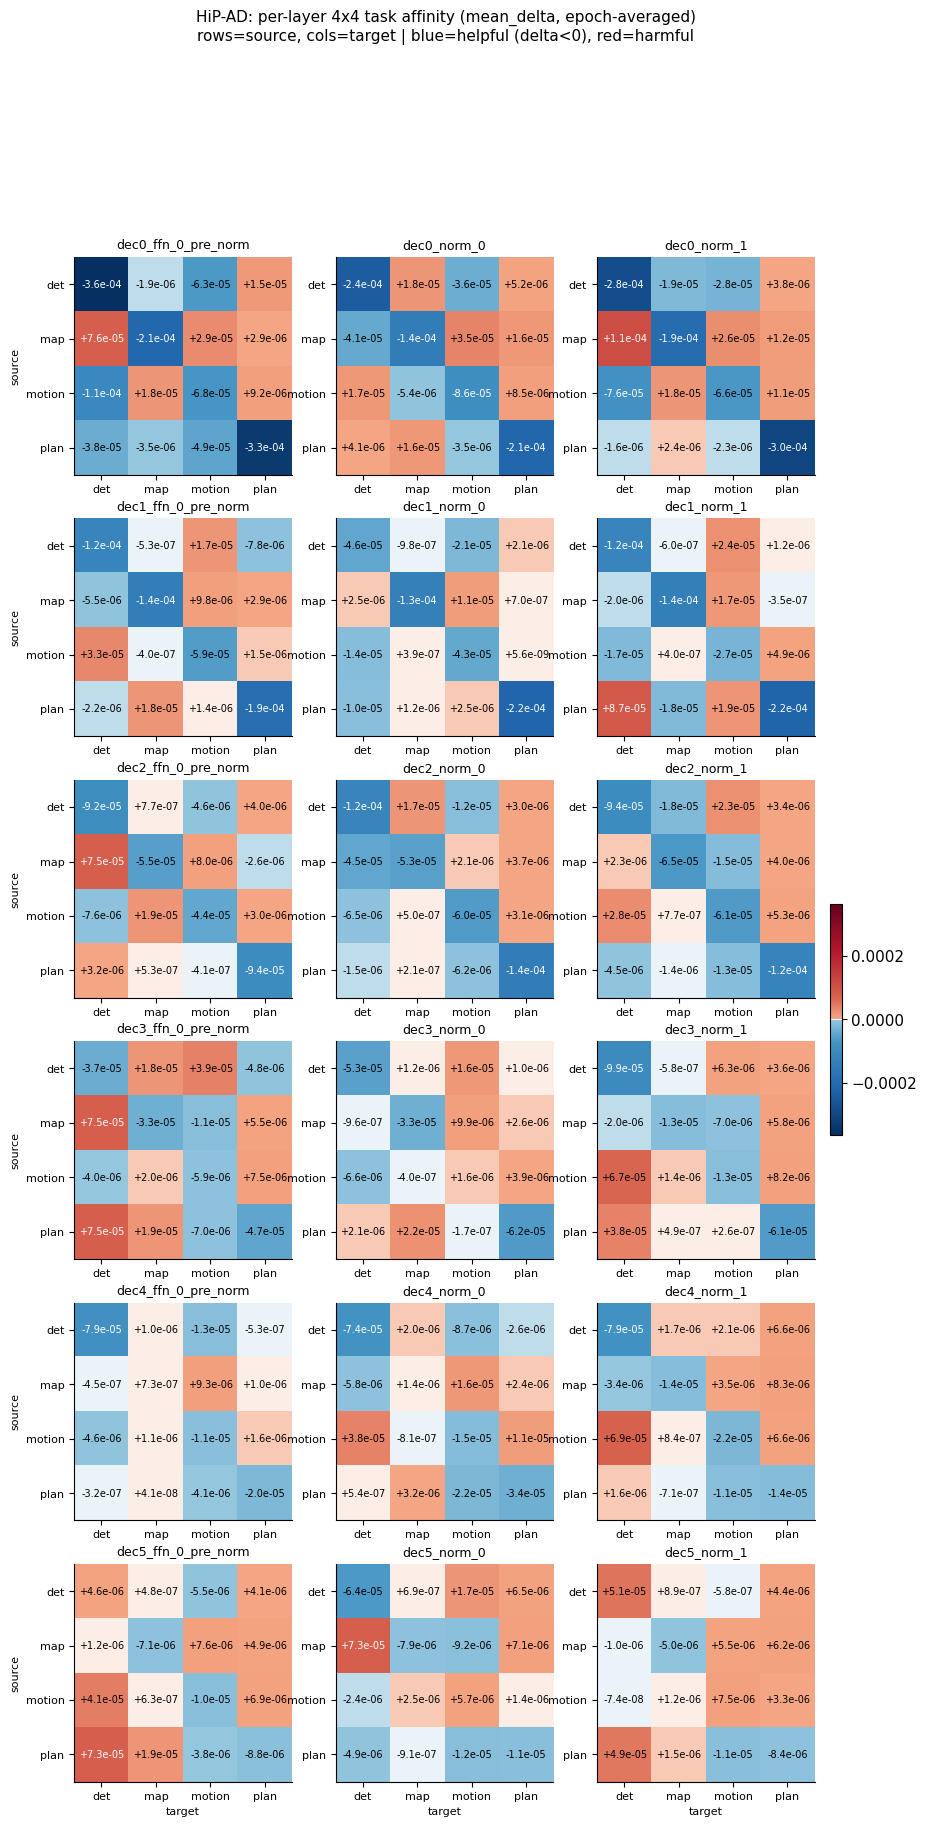

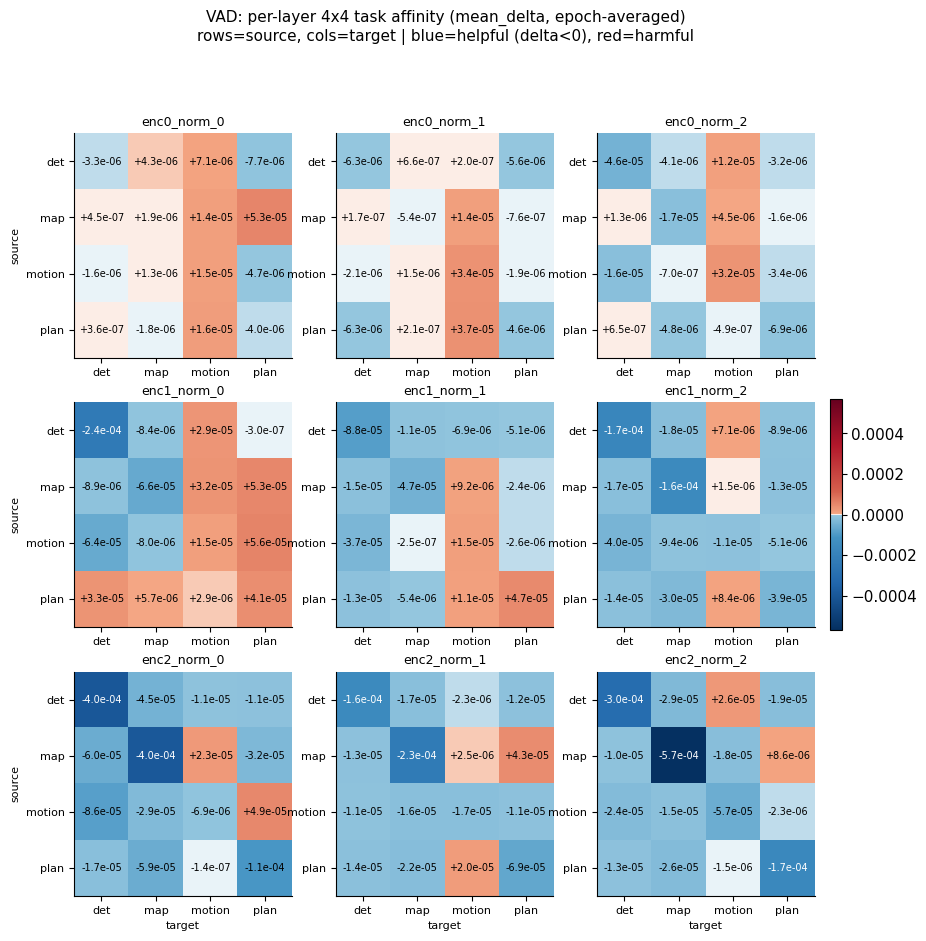

In [11]:
def plot_probe_layer_grid(probe_layer, metric, fmt, model):
    """Per-layer 4x4 source->target matrix grid for one model (epoch-averaged)."""
    sub = probe_layer[probe_layer['model'] == model]
    if sub.empty:
        print(f'[{model}] no probe layers'); return
    layers = sorted(sub['layer'].unique())
    blocks = sorted({_parse_layer(L)[0] for L in layers})
    subkeys = sorted({_parse_layer(L)[1] for L in layers})

    mats = {}
    for L in layers:
        m = (sub[sub['layer'] == L]
             .pivot_table(index='source_task', columns='target_task', values=metric)
             .reindex(index=TASKS, columns=TASKS))
        mats[L] = m
    vlim = float(np.nanmax([np.nanmax(np.abs(m.values)) for m in mats.values()])) or 1.0

    fig, axes = plt.subplots(len(blocks), len(subkeys),
                             figsize=(3.3 * len(subkeys), 3.3 * len(blocks)),
                             squeeze=False)
    im = None
    for r, blk in enumerate(blocks):
        for c, sk in enumerate(subkeys):
            ax = axes[r][c]
            L = f'{blk}_{sk}'
            if L not in mats:
                ax.axis('off'); continue
            mat = mats[L]
            im = ax.imshow(mat.values, cmap=NARROW_RDBU, vmin=-vlim, vmax=vlim, aspect='auto')
            ax.set_xticks(range(len(TASKS))); ax.set_xticklabels(TASKS, fontsize=8)
            ax.set_yticks(range(len(TASKS))); ax.set_yticklabels(TASKS, fontsize=8)
            ax.set_title(L, fontsize=9); ax.grid(False)
            if r == len(blocks) - 1:
                ax.set_xlabel('target', fontsize=8)
            if c == 0:
                ax.set_ylabel('source', fontsize=8)
            for i in range(len(TASKS)):
                for j in range(len(TASKS)):
                    v = mat.values[i, j]
                    if not np.isfinite(v):
                        continue
                    color = 'white' if abs(v) > TEXT_FLIP * vlim else 'black'
                    ax.text(j, i, fmt.format(v), ha='center', va='center',
                            fontsize=7, color=color)
    fig.suptitle(f'{model}: per-layer 4x4 task affinity ({metric}, epoch-averaged)\n'
                 f'rows=source, cols=target | blue=helpful (delta<0), red=harmful',
                 y=1.005, fontsize=11)
    if im is not None:
        fig.colorbar(im, ax=axes, fraction=0.015, pad=0.02)
    plt.show()


if not probe_layer.empty:
    for model in sorted(probe_layer['model'].unique()):
        plot_probe_layer_grid(probe_layer, 'mean_delta', '{:+.1e}', model)

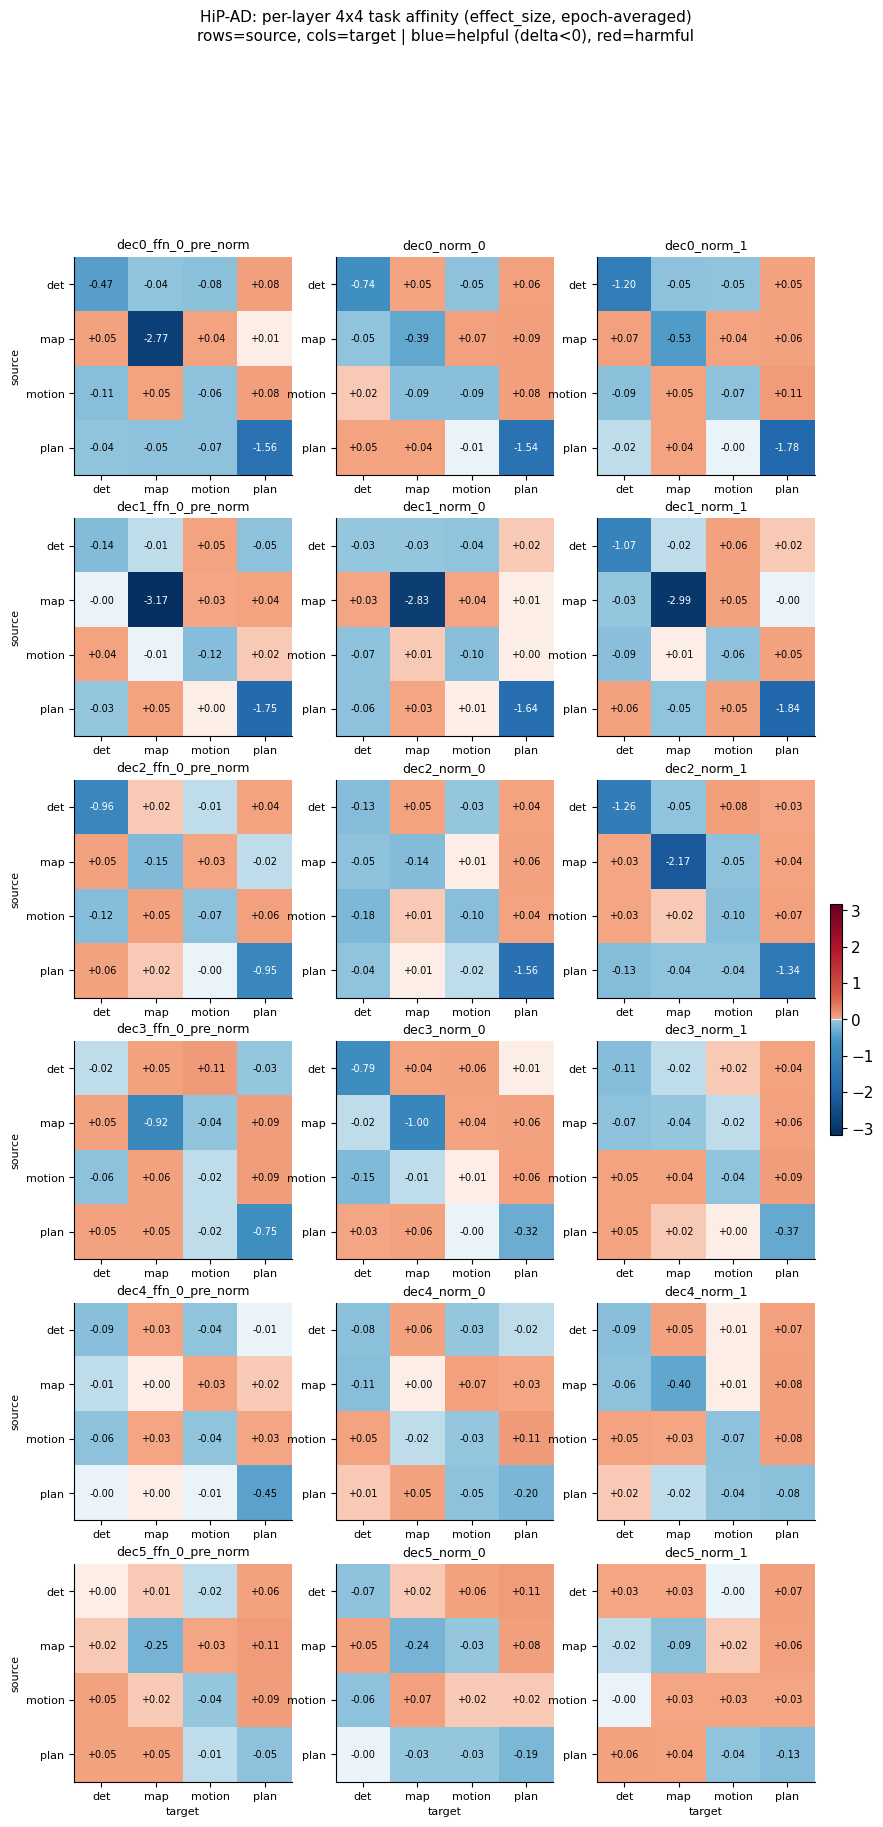

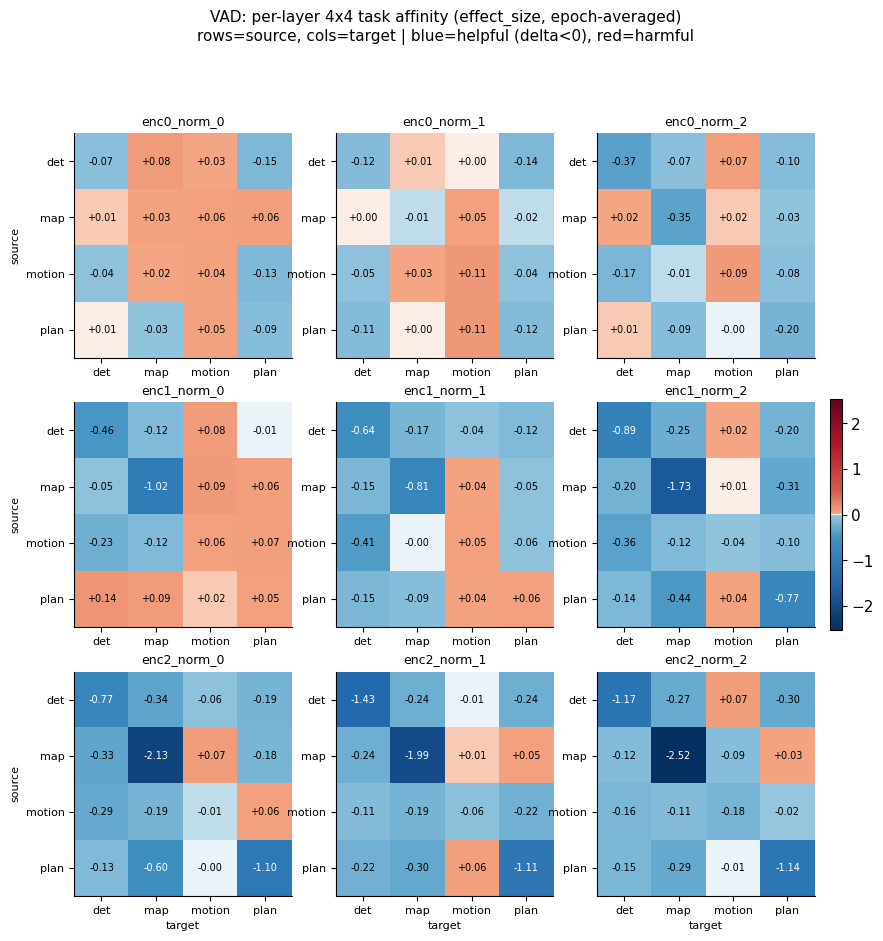

In [12]:
# effect_size (Cohen's d 부호) per-layer grid: 분산 대비 신호 크기
if not probe_layer.empty:
    for model in sorted(probe_layer['model'].unique()):
        plot_probe_layer_grid(probe_layer, 'effect_size', '{:+.2f}', model)

In [13]:
# layer별 off-diagonal(cross-task) 평균 affinity 순위 — 어느 layer가 가장 간섭이 큰가
if not probe_layer.empty:
    cross = probe_layer[probe_layer['source_task'] != probe_layer['target_task']].copy()
    rank = (cross.groupby(['model', 'layer'])
                 .agg(mean_abs_delta=('mean_delta', lambda s: s.abs().mean()),
                      mean_cross_delta=('mean_delta', 'mean'),
                      mean_helpful_rate=('helpful_rate', 'mean'))
                 .reset_index()
                 .sort_values(['model', 'mean_abs_delta'], ascending=[True, False]))
    print('=== Per-layer cross-task interference ranking (epoch-averaged) ===')
    display(rank.reset_index(drop=True))

=== Per-layer cross-task interference ranking (epoch-averaged) ===


,model,layer,mean_abs_delta,mean_cross_delta,mean_helpful_rate
0,HiP-AD,dec0_ffn_0_pre_norm,0.000034,-9.311667e-06,0.519583
1,HiP-AD,dec0_norm_1,0.000026,4.638092e-06,0.510625
2,HiP-AD,dec3_ffn_0_pre_norm,0.000022,1.793084e-05,0.495625
3,HiP-AD,dec0_norm_0,0.000017,2.803622e-06,0.511250
4,HiP-AD,dec1_norm_1,0.000016,9.578907e-06,0.504375
5,HiP-AD,dec5_ffn_0_pre_norm,0.000014,1.252069e-05,0.484583
6,HiP-AD,dec3_norm_1,0.000012,1.007709e-05,0.502292
7,HiP-AD,dec5_norm_0,0.000012,6.655231e-06,0.482917
8,HiP-AD,dec2_ffn_0_pre_norm,0.000011,8.142175e-06,0.497708
9,HiP-AD,dec2_norm_1,0.000010,1.245433e-06,0.504375


**해석 포인트 (6.1)**

- decoder 가 깊어질수록(dec0→dec5) off-diagonal affinity 가 커지거나 작아지는 추세가 있으면,
  task 간섭이 특정 깊이에 몰린다는 뜻 — 그 layer 가 surgery/weighting 의 우선 대상.
- 같은 decoder 안에서 `norm_0` / `norm_1` / `ffn_0_pre_norm` 중 어디서 affinity 가 강한지 보면
  간섭이 attention 경로인지 FFN 경로인지 좁힐 수 있습니다.
- `effect_size` grid 색이 옅으면(|d|<0.2) mean_delta 의 부호가 분산에 묻히는 것 — layer 평균이라도
  신호가 약하면 그 layer 의 transfer 는 보고에서 약하게 다뤄야 합니다.


## 7. Epoch dynamics

`v3/dynamics/` 는 epoch(=checkpoint)별로 conflict / helpful 신호를 시계열로 모은 산출물입니다.
**HiP-AD 전용** 산출물입니다 (VAD v3 에는 `dynamics/` 디렉터리가 없음).

- `cos_dynamics.csv`: `epoch, pair, group, mean_cos, conflict_ratio`
- `helpful_dynamics.csv`: `epoch, pair, helpful_ratio` (pair 는 `source→target` 방향)


In [14]:
DYN_DIR = RESULTS_ROOT / 'v3' / 'dynamics'
cos_dyn = pd.read_csv(DYN_DIR / 'cos_dynamics.csv') if (DYN_DIR / 'cos_dynamics.csv').exists() else pd.DataFrame()
hlp_dyn = pd.read_csv(DYN_DIR / 'helpful_dynamics.csv') if (DYN_DIR / 'helpful_dynamics.csv').exists() else pd.DataFrame()
print('cos_dynamics:', cos_dyn.shape, '| helpful_dynamics:', hlp_dyn.shape)
if not cos_dyn.empty:
    display(cos_dyn.head())
if not hlp_dyn.empty:
    display(hlp_dyn.head())

cos_dynamics: (72, 5) | helpful_dynamics: (48, 3)


,epoch,pair,group,mean_cos,conflict_ratio
0,1.0,motion|plan,fc_after,-0.001523,0.52
1,1.0,motion|plan,fc_before,-0.012597,0.55
2,1.0,motion|plan,neck,-0.003161,0.50
3,1.0,det|motion,fc_after,0.067848,0.25
4,1.0,det|motion,fc_before,0.062722,0.36


,epoch,pair,helpful_ratio
0,1.0,det→map,0.495556
1,1.0,det→motion,0.496667
2,1.0,det→plan,0.503889
3,1.0,map→det,0.472222
4,1.0,map→motion,0.503889


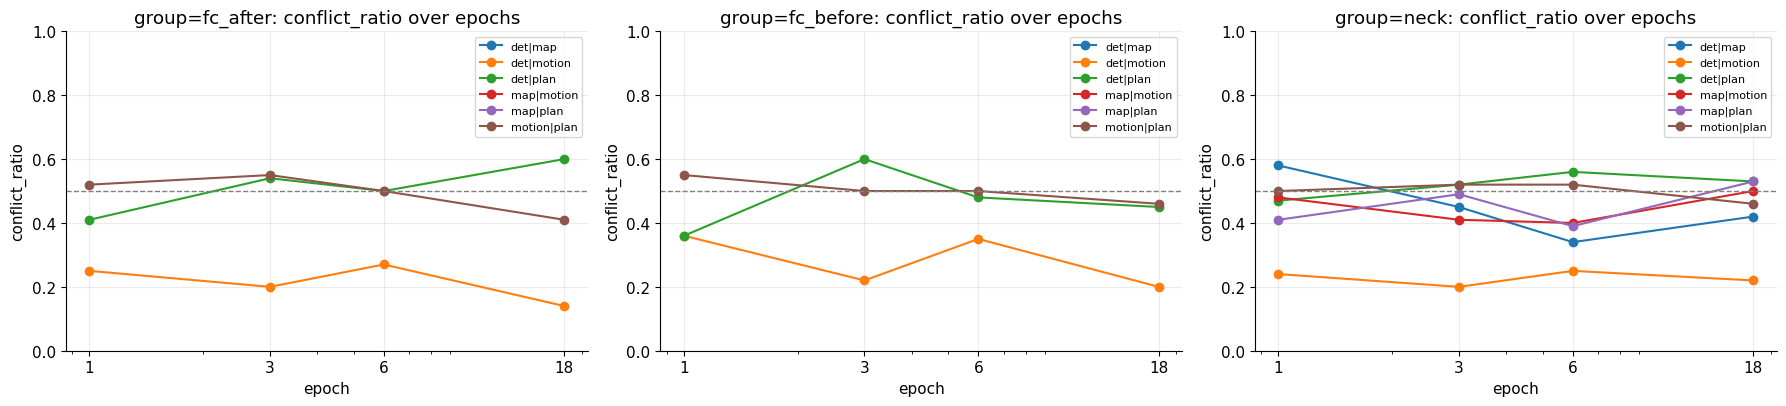

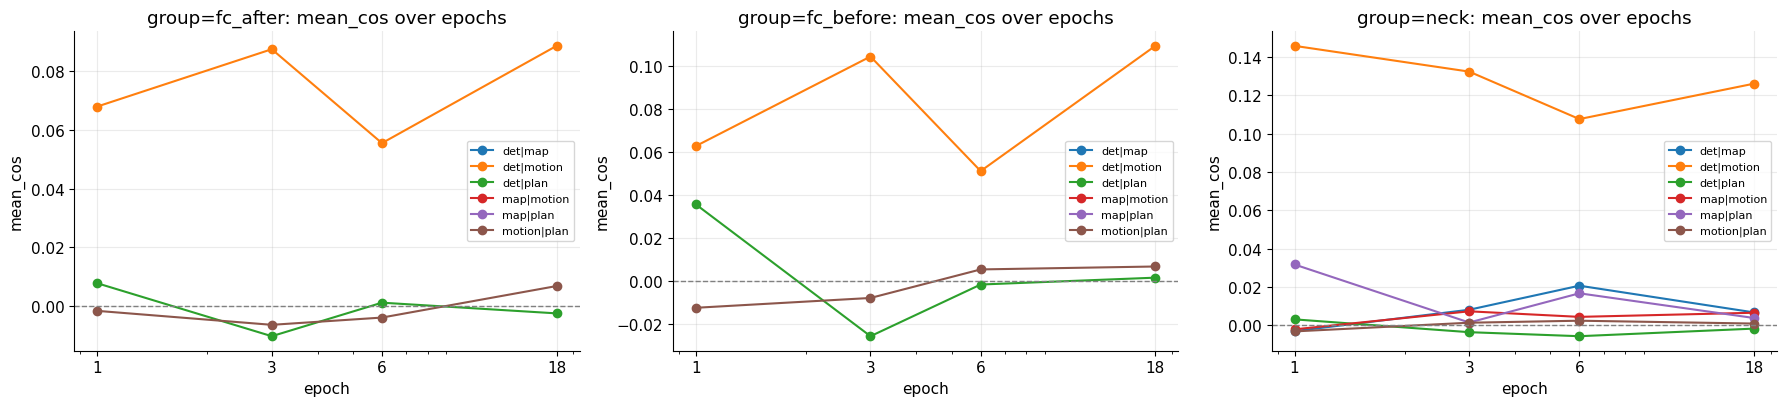

In [15]:
# conflict_ratio & mean_cos over epochs, faceted by group
if not cos_dyn.empty:
    groups = sorted(cos_dyn['group'].unique())
    for metric, ref in [('conflict_ratio', 0.5), ('mean_cos', 0.0)]:
        fig, axes = plt.subplots(1, len(groups), figsize=(6 * len(groups), 4.2), squeeze=False)
        for ax, grp in zip(axes[0], groups):
            sub = cos_dyn[cos_dyn['group'] == grp]
            for pair, pdf in sub.groupby('pair'):
                pdf = pdf.sort_values('epoch')
                ax.plot(pdf['epoch'], pdf[metric], marker='o', label=pair)
            ax.axhline(ref, color='gray', ls='--', lw=1)
            ax.set_title(f'group={grp}: {metric} over epochs')
            ax.set_xlabel('epoch'); ax.set_ylabel(metric)
            ax.set_xscale('log'); ax.set_xticks(sorted(cos_dyn['epoch'].unique()))
            ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
            if metric == 'conflict_ratio':
                ax.set_ylim(0, 1)
            ax.legend(fontsize=8)
        plt.tight_layout(); plt.show()
else:
    print('cos_dynamics empty')

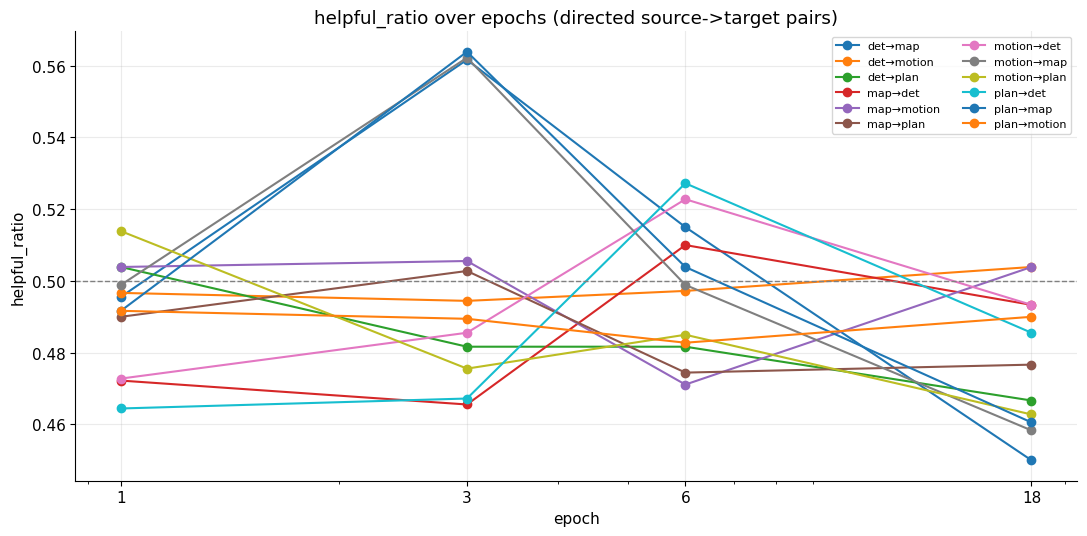

=== helpful_ratio ranking at epoch 18 ===


,epoch,pair,helpful_ratio
0,18.0,det→motion,0.503889
1,18.0,map→motion,0.503889
2,18.0,map→det,0.493333
3,18.0,motion→det,0.493333
4,18.0,plan→motion,0.490000
5,18.0,plan→det,0.485556
6,18.0,map→plan,0.476667
7,18.0,det→plan,0.466667
8,18.0,motion→plan,0.462778
9,18.0,plan→map,0.460556


In [16]:
# helpful_ratio over epochs, directed pairs
if not hlp_dyn.empty:
    fig, ax = plt.subplots(figsize=(11, 5.5))
    for pair, pdf in hlp_dyn.groupby('pair'):
        pdf = pdf.sort_values('epoch')
        ax.plot(pdf['epoch'], pdf['helpful_ratio'], marker='o', label=pair)
    ax.axhline(0.5, color='gray', ls='--', lw=1)
    ax.set_title('helpful_ratio over epochs (directed source->target pairs)')
    ax.set_xlabel('epoch'); ax.set_ylabel('helpful_ratio')
    ax.set_xscale('log'); ax.set_xticks(sorted(hlp_dyn['epoch'].unique()))
    ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
    ax.legend(fontsize=8, ncol=2)
    plt.tight_layout(); plt.show()

    # final-epoch helpful ranking
    last = hlp_dyn['epoch'].max()
    rank = hlp_dyn[hlp_dyn['epoch'] == last].sort_values('helpful_ratio', ascending=False)
    print(f'=== helpful_ratio ranking at epoch {last:g} ===')
    display(rank.reset_index(drop=True))
else:
    print('helpful_dynamics empty')

timeseries_cosine.png


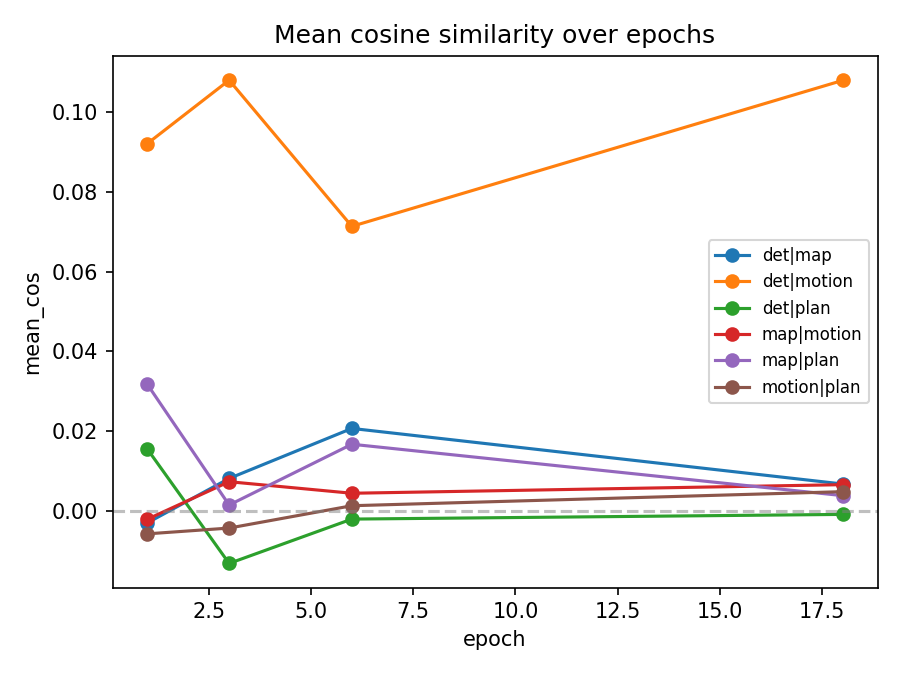

timeseries_conflict_ratio.png


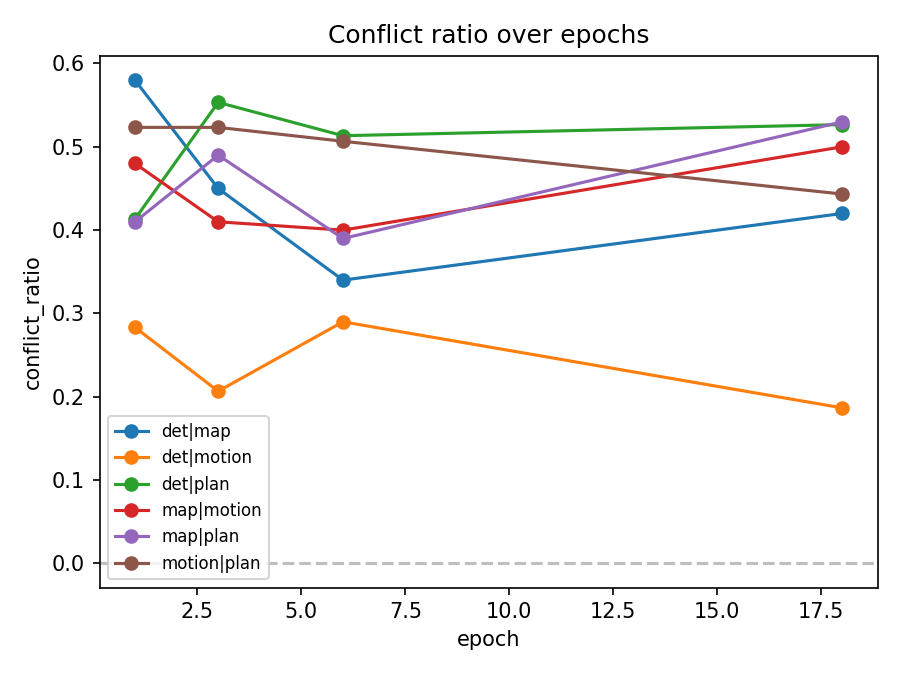

timeseries_helpful.png


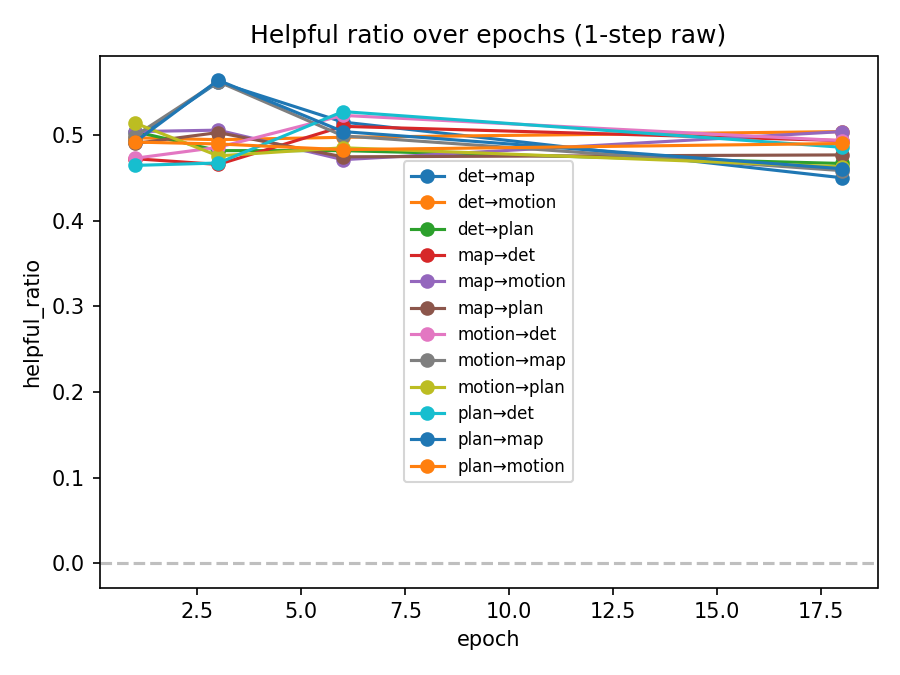

In [17]:
# Pre-generated timeseries PNGs shipped with v3/dynamics
from IPython.display import Image
for png in ['timeseries_cosine.png', 'timeseries_conflict_ratio.png', 'timeseries_helpful.png']:
    p = DYN_DIR / png
    if p.exists():
        print(png)
        display(Image(filename=str(p)))
    else:
        print(f'[missing] {png}')

**해석 포인트**

- conflict_ratio 가 epoch 이 진행되며 0.5 로 수렴/하향하면, 학습 후반에는 direction conflict
  자체가 약해진다는 뜻입니다 (초기 epoch 에 surgery 가 더 의미 있음).
- helpful_ratio 가 특정 방향(예: `det→plan`)에서 꾸준히 0.5 위/아래면, 그 transfer 는 학습
  내내 일관된 부호를 갖습니다 — task weighting 설계의 근거가 됩니다.


## 8. Query sensitivity (v3 신규)

`query_sensitivity/qs.csv` 는 v3 에서 **새로 추가된** 산출물입니다 (옛 `hipad_layer` 실행에는 없음).

각 query token 에 대해 **planning loss 의 gradient 가 그 query 까지 얼마나 도달하는지**를
`grad_plan_wrt_query_norm = ||∂L_plan / ∂query||` 로 측정합니다.

- `task_query_type`: 그 query 가 어느 task 의 query 인지 (`det`/`map`/`motion`/`plan`).
- `query_norm`: query token 자체의 norm.
- `grad_plan_wrt_query_norm`: planning gradient 가 그 query 로 흘러든 크기. **0 이면 planning
  gradient 가 그 query 에 전혀 도달하지 않음**.

핵심 질문: planning 의 학습 신호가 다른 task 의 query representation 까지 전파되는가?
(전파된다면 plan-centric multi-task coupling 이 query level 에서 존재한다는 뜻)

> HiP-AD 전용 산출물입니다 (VAD v3 에는 `query_sensitivity/` 가 없음).
> 큰 파일이므로 `v3/plan_centric/query_sensitivity.csv` 집계본을 우선 사용하고,
> 없으면 per-checkpoint `qs.csv` 를 직접 읽습니다.


In [18]:
QS_COLS = ['checkpoint', 'checkpoint_order', 'task_query_type',
           'query_norm', 'grad_plan_wrt_query_norm']
QS_DTYPE = {'checkpoint': 'category', 'checkpoint_order': 'int16',
            'task_query_type': 'category', 'query_norm': 'float32',
            'grad_plan_wrt_query_norm': 'float32'}

_qs_top = RESULTS_ROOT / 'v3' / 'plan_centric' / 'query_sensitivity.csv'
qs = pd.DataFrame()
if _qs_top.exists():
    qs = pd.read_csv(_qs_top, usecols=QS_COLS, dtype=QS_DTYPE)
    print(f'loaded aggregate: {_qs_top.name}  rows={len(qs):,}')
else:
    frames = []
    for ckpt in checkpoint_dirs(RESULTS_ROOT / 'v3'):
        p = ckpt / 'query_sensitivity' / 'qs.csv'
        if p.exists():
            frames.append(pd.read_csv(p, usecols=QS_COLS, dtype=QS_DTYPE))
    qs = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
    print(f'loaded per-checkpoint qs.csv  rows={len(qs):,}')

loaded aggregate: query_sensitivity.csv  rows=15,362,400


In [19]:
if not qs.empty:
    g = (qs.groupby(['checkpoint_order', 'checkpoint', 'task_query_type'], observed=True)
           .agg(n_queries=('grad_plan_wrt_query_norm', 'size'),
                mean_grad=('grad_plan_wrt_query_norm', 'mean'),
                max_grad=('grad_plan_wrt_query_norm', 'max'),
                frac_reached=('grad_plan_wrt_query_norm', lambda s: (s > 0).mean()),
                mean_query_norm=('query_norm', 'mean'))
           .reset_index().sort_values(['checkpoint_order', 'task_query_type']))
    print('=== planning-gradient reach into each task\'s queries ===')
    display(g.drop(columns='checkpoint_order'))
else:
    print('query_sensitivity empty')

=== planning-gradient reach into each task's queries ===


,checkpoint,task_query_type,n_queries,mean_grad,max_grad,frac_reached,mean_query_norm
0,1ep,det,540000,0.000000,0.000000,0.000000,15.923862
1,1ep,map,60000,0.000000,0.000000,0.000000,15.933801
2,1ep,motion,3240000,0.000000,0.000000,0.000000,27.187889
3,1ep,plan,600,0.002330,0.007644,0.978333,15.952561
4,3ep,det,540000,0.000000,0.000000,0.000000,15.847622
5,3ep,map,60000,0.000000,0.000000,0.000000,15.848144
6,3ep,motion,3240000,0.000000,0.000000,0.000000,26.395370
7,3ep,plan,600,0.001583,0.012257,0.978333,15.875659
8,6ep,det,540000,0.000000,0.000000,0.000000,15.780920
9,6ep,map,60000,0.000000,0.000000,0.000000,15.774315


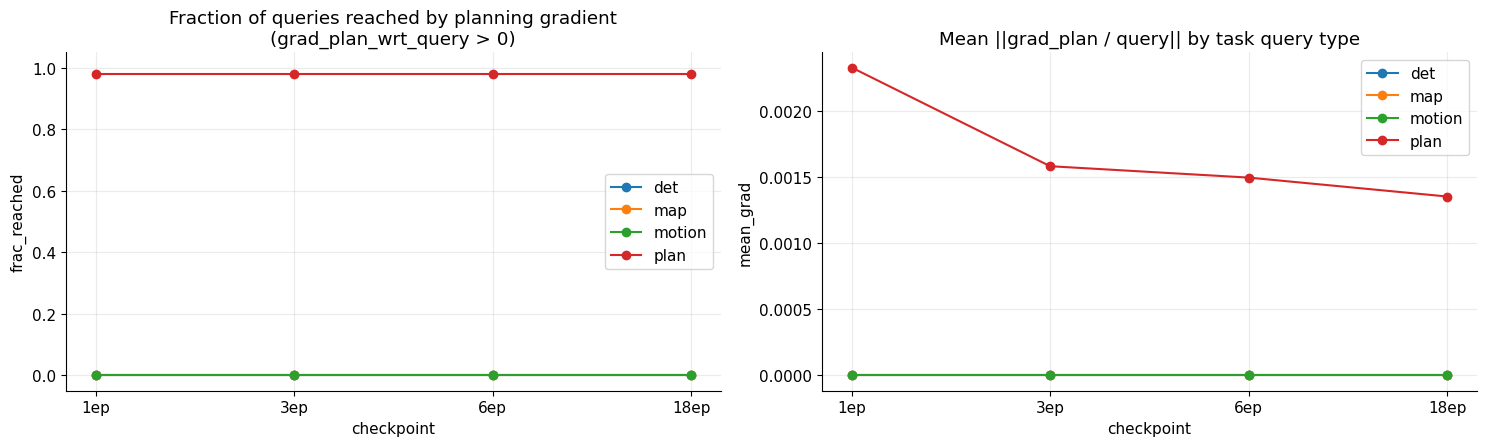

In [20]:
if not qs.empty:
    order = (g.drop_duplicates('checkpoint').sort_values('checkpoint_order')['checkpoint'].tolist())
    qtypes = ['det', 'map', 'motion', 'plan']

    fig, axes = plt.subplots(1, 2, figsize=(15, 4.6))
    # (a) fraction of queries the planning gradient actually reaches
    for qt in qtypes:
        s = g[g['task_query_type'] == qt].set_index('checkpoint').reindex(order)
        axes[0].plot(order, s['frac_reached'].values, marker='o', label=qt)
    axes[0].set_title('Fraction of queries reached by planning gradient\n(grad_plan_wrt_query > 0)')
    axes[0].set_xlabel('checkpoint'); axes[0].set_ylabel('frac_reached')
    axes[0].set_ylim(-0.05, 1.05); axes[0].legend()
    # (b) mean planning-gradient magnitude into each task's queries
    for qt in qtypes:
        s = g[g['task_query_type'] == qt].set_index('checkpoint').reindex(order)
        axes[1].plot(order, s['mean_grad'].values, marker='o', label=qt)
    axes[1].set_title('Mean ||grad_plan / query|| by task query type')
    axes[1].set_xlabel('checkpoint'); axes[1].set_ylabel('mean_grad')
    axes[1].legend()
    plt.tight_layout(); plt.show()

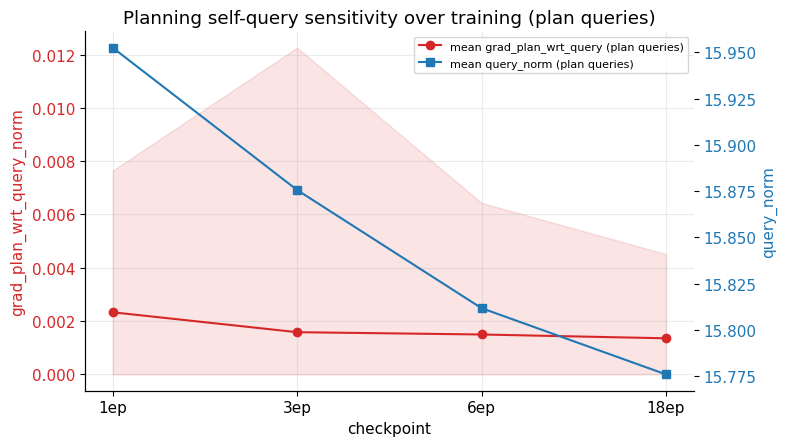

In [21]:
if not qs.empty:
    # plan queries only: sensitivity decay + query norm over training
    planq = g[g['task_query_type'] == 'plan'].sort_values('checkpoint_order')
    fig, ax1 = plt.subplots(figsize=(8, 4.6))
    ax1.plot(planq['checkpoint'], planq['mean_grad'], marker='o', color='C3',
             label='mean grad_plan_wrt_query (plan queries)')
    ax1.fill_between(planq['checkpoint'], 0, planq['max_grad'], color='C3', alpha=0.12,
                     label='max grad (plan queries)')
    ax1.set_xlabel('checkpoint'); ax1.set_ylabel('grad_plan_wrt_query_norm', color='C3')
    ax1.tick_params(axis='y', labelcolor='C3')
    ax2 = ax1.twinx()
    ax2.plot(planq['checkpoint'], planq['mean_query_norm'], marker='s', color='C0',
             label='mean query_norm (plan queries)')
    ax2.set_ylabel('query_norm', color='C0'); ax2.tick_params(axis='y', labelcolor='C0')
    ax2.grid(False)
    ax1.set_title('Planning self-query sensitivity over training (plan queries)')
    lines = ax1.get_lines() + ax2.get_lines()
    ax1.legend(lines, [l.get_label() for l in lines], fontsize=8, loc='upper right')
    plt.tight_layout(); plt.show()

**해석 포인트**

- det/map/motion query 의 `frac_reached`/`mean_grad` 가 0 이면, planning gradient 가 그 task 의
  query representation 까지 **전혀 전파되지 않는다**는 뜻입니다. 이 경우 plan↔(det/map/motion)
  coupling 은 적어도 query level 에서는 존재하지 않으며, 상호작용은 shared backbone/neck
  파라미터를 통해서만 일어납니다 (Part 2~6 의 conflict/probe 가 그 경로를 봅니다).
- plan query 만 nonzero 라면 그것은 planning head 의 self-sensitivity 입니다. epoch 이 진행되며
  `mean_grad` 가 감소하면 planning 이 자기 query 에 점점 덜 민감해진다(수렴) 는 신호입니다.
- `query_norm` 추세는 representation scale 변화를 보여줍니다. grad 와 norm 을 같이 봐야
  "민감도 감소" 가 진짜인지 단순 scale 변화 때문인지 구분됩니다.


## 9. Planning-aligned task importance (item 3 신규)

direction.md item 3 — **"planning에 도움 주는 task를 어떻게 판단할 것인가"** 를 정량화하는 섹션입니다.
재실행으로 `inter_gnn` 스코프(`dec{0..5}_inter_gnn_0`)에 한정해 산출된 `layer_conflict/` +
`probe/` CSV 를 사용해 다음을 봅니다.

- **Alignment** `A_i = cos(g_i, g_plan)` (`direction.md` 정의)
- **Transfer**  `T_i = -ΔL_plan | source=i` (causal)
- **Scene-dependence**: batch 별 winner 분포 + 정규화 엔트로피
- **Agreement**: alignment ↔ transfer Spearman, per-batch winner 일치율, 부호 일치율
- **motion det-collinearity**: motion 은 query 가 없어 det 경로로 흐르므로 `cos(g_motion, g_det)` 동선성 플래그
- **planning layer-sensitivity** (item 2 보조): inter_gnn decoder 별 `||g_plan||`

설계 문서:
[`docs/superpowers/specs/2026-05-23-planning-aligned-task-importance-design.md`](
../2026-05-23-planning-aligned-task-importance-design.md).


In [ ]:
# Planning-importance 출력 위치. 데이터가 아직 없는 경우 셀은 안전하게 NoOp.
from pathlib import Path
import pandas as pd

# 분석 결과 루트 — checkpoint별 디렉터리 안에 planning_importance/ 가 있다고 가정.
# 데이터를 새로 받아 붙일 때 RESULTS_ROOT 와 CKPT_TAG 만 바꿔주면 된다.
RESULTS_ROOT = Path("/home/yongjae/e2e/HiP-AD/gradient_analysis_results")
CKPT_TAG     = "18ep"   # 분석 대상 ckpt

PI_DIR = RESULTS_ROOT / f"ckpt_{CKPT_TAG}" / "planning_importance"
print(f"planning_importance dir: {PI_DIR}")
print(f"exists: {PI_DIR.exists()}")

def _safe_csv(path):
    p = Path(path)
    if not p.exists():
        return pd.DataFrame()
    try:
        df = pd.read_csv(p)
    except (pd.errors.EmptyDataError, pd.errors.ParserError):
        return pd.DataFrame()
    return df

pi_summary    = _safe_csv(PI_DIR / "importance_summary.csv")
pi_winner_pb  = _safe_csv(PI_DIR / "scene_winner_per_batch.csv")
pi_winner_dst = _safe_csv(PI_DIR / "scene_winner_distribution.csv")
pi_agreement  = _safe_csv(PI_DIR / "alignment_transfer_agreement.csv")
pi_layer_sens = _safe_csv(PI_DIR / "planning_layer_sensitivity.csv")

print("loaded rows:",
      "summary=", len(pi_summary),
      "winner_per_batch=", len(pi_winner_pb),
      "winner_distribution=", len(pi_winner_dst),
      "agreement=", len(pi_agreement),
      "layer_sensitivity=", len(pi_layer_sens))

In [ ]:
# § 9.1 Importance summary — alignment (cos) and transfer (gain) per aux task + 95% CI.
import numpy as np
import matplotlib.pyplot as plt

if pi_summary.empty:
    print("[planning_importance] no data yet — connect ckpts/data first.")
else:
    display(pi_summary)
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    s = pi_summary.set_index("aux_task")
    tasks = list(s.index)
    x = np.arange(len(tasks))

    ax = axes[0]
    ax.bar(x, s["align_score"], color="steelblue",
           yerr=[s["align_score"] - s["align_ci_lo"], s["align_ci_hi"] - s["align_score"]],
           capsize=4)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xticks(x); ax.set_xticklabels(tasks)
    ax.set_ylabel("mean cos(g_aux, g_plan)")
    ax.set_title("Alignment at inter_gnn (positive = helpful)")

    ax = axes[1]
    ax.bar(x, s["transfer_gain"], color="indianred",
           yerr=[s["transfer_gain"] - s["transfer_ci_lo"],
                 s["transfer_ci_hi"] - s["transfer_gain"]],
           capsize=4)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xticks(x); ax.set_xticklabels(tasks)
    ax.set_ylabel("mean gain = -ΔL_plan")
    ax.set_title("Probe transfer to planning (positive = helpful)")
    plt.tight_layout(); plt.show()

In [ ]:
# § 9.2 Scene-dependence — winner distribution + normalized entropy.
if pi_winner_dst.empty:
    print("[planning_importance] no winner distribution — skipping.")
else:
    display(pi_winner_dst)
    metrics = pi_winner_dst["metric"].unique().tolist()
    fig, axes = plt.subplots(1, len(metrics), figsize=(5.5 * len(metrics), 3.8), squeeze=False)
    for ax, metric in zip(axes[0], metrics):
        sub = pi_winner_dst[pi_winner_dst["metric"] == metric]
        H = float(sub["normalized_entropy"].iloc[0])
        ax.bar(sub["aux_task"], sub["win_frac"], color="seagreen")
        ax.set_ylim(0, 1)
        ax.set_ylabel("fraction of batches where this task wins")
        ax.set_title(f"{metric}: scene winner — H_norm = {H:.3f}")
    plt.tight_layout(); plt.show()
    print("Normalized entropy:")
    print("  ~0  → 한 task 가 거의 항상 1등 (scene-무관)")
    print("  ~1  → task 가 고루 1등 (scene 의존성 강함, distillation per-scene weighting 근거)")

In [ ]:
# § 9.3 Agreement — does cheap cosine proxy track causal probe transfer?
if pi_agreement.empty:
    print("[planning_importance] no agreement metrics — skipping.")
else:
    display(pi_agreement.T.rename(columns={0: "value"}))
    print()
    sp = float(pi_agreement["spearman"].iloc[0]) if "spearman" in pi_agreement else float("nan")
    wa = float(pi_agreement["per_batch_winner_agreement"].iloc[0]) \
            if "per_batch_winner_agreement" in pi_agreement else float("nan")
    sa = float(pi_agreement["sign_agreement"].iloc[0]) if "sign_agreement" in pi_agreement else float("nan")
    print(f"Spearman(cos, gain)       : {sp:+.3f}   (1.0 = 완전 동조)")
    print(f"per-batch winner agreement: {wa:+.3f}   (1.0 = 모든 batch에서 두 metric의 1등이 같음)")
    print(f"sign agreement            : {sa:+.3f}   (1.0 = 부호 항상 일치)")

In [ ]:
# § 9.4 Per-batch winner sequence (scene 의존성 시각화).
if pi_winner_pb.empty:
    print("[planning_importance] no per-batch winner data — skipping.")
else:
    metrics = pi_winner_pb["metric"].unique().tolist()
    aux_order = ["det", "map", "motion"]
    fig, axes = plt.subplots(len(metrics), 1, figsize=(11, 3.0 * len(metrics)),
                             squeeze=False, sharex=True)
    for ax, metric in zip(axes[:, 0], metrics):
        sub = pi_winner_pb[pi_winner_pb["metric"] == metric].sort_values("batch_idx")
        if sub.empty:
            ax.set_title(f"{metric}: (empty)"); continue
        ax.scatter(sub["batch_idx"],
                   sub["winner_task"].map({t: i for i, t in enumerate(aux_order)}),
                   c=sub["winner_task"].map({"det": "C0", "map": "C1", "motion": "C2"}),
                   s=18)
        ax.set_yticks(range(len(aux_order))); ax.set_yticklabels(aux_order)
        ax.set_title(f"Per-batch winner — {metric}")
        ax.set_ylabel("winner task")
    axes[-1][0].set_xlabel("batch_idx")
    plt.tight_layout(); plt.show()

In [ ]:
# § 9.5 motion det-collinearity + planning layer-sensitivity.
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

ax = axes[0]
if pi_summary.empty:
    ax.set_title("motion det-collinearity (no data)")
else:
    s = pi_summary.set_index("aux_task")
    coll = s.loc["motion", "motion_det_collinearity"] if "motion" in s.index else float("nan")
    flag = bool(s.loc["motion", "flag_det_collinear"]) if "motion" in s.index else False
    ax.bar(["motion ↔ det"], [coll if coll == coll else 0.0],
           color="purple" if flag else "lightsteelblue")
    ax.axhline(0.8, color="red", linestyle="--", linewidth=1, label="threshold 0.8")
    ax.set_ylim(0, 1); ax.set_ylabel("cos(g_motion, g_det) at inter_gnn")
    ax.set_title(f"motion det-collinearity = {coll:.3f}   flag = {flag}")
    ax.legend(loc="upper right")

ax = axes[1]
if pi_layer_sens.empty:
    ax.set_title("planning layer-sensitivity (no data)")
else:
    ls = pi_layer_sens.sort_values("layer")
    ax.bar(ls["layer"], ls["mean_grad_norm"], color="darkorange")
    ax.set_xticklabels(ls["layer"], rotation=30, ha="right")
    ax.set_ylabel("mean ||g_plan||")
    ax.set_title("planning sensitivity per inter_gnn layer (item 2 보조)")
plt.tight_layout(); plt.show()

**해석 포인트 (§ 9)**

- `align_score > 0` 인 task = planning gradient 와 같은 방향으로 shared params 를 바꾸려는 task.
  `transfer_gain > 0` 도 마찬가지(causal). 둘이 같은 task 를 가리키면 **online cosine proxy 가 신뢰됨** → distillation per-scene weighting 의 근거.
- `normalized_entropy` 가 0.5 이상이면 "scene 마다 중요 task 가 다르다"는 direction.md 의 주장이 정량적으로 뒷받침됨. 0 에 가까우면 한 task 가 늘 우세 → static weighting 으로 충분.
- `flag_det_collinear=True` (motion) 이면 motion 의 importance 는 사실상 det pathway 의 재가중치라
  해석에 주의. motion 을 1등급 보조 task 로 다루지 말고 "det 를 거치는 간접 기여" 로 다루는 게 합리적.
- `planning layer-sensitivity` 가 특정 decoder 에 몰리면(예: dec5 가 압도) 그 위치의 inter_gnn 이
  surgery/weighting 의 우선순위. 균일하면 layer-wise per-decoder 가중이 필요할 수 있음.


## 10. 정리

이 노트북은 v3 산출물에 대해 다음을 확인했습니다.

1. **Conflict** — real group 기준 conflict_ratio 의 분포와 가장 충돌이 큰/작은 pair·group.
2. **Null-baseline** — conflict 신호가 permutation/sign-flip noise 와 구분되는지 (Phase 1 30% 기준).
3. **Distribution** — cosine 분포 형태와 bimodal(평균이 오해를 주는) 셀.
4. **Layer correlation** — cosine 이 1-step loss 변화를 얼마나 예측하는지.
5. **1-step probe** — source→target transfer 의 부호/크기 및 helpful_rate.
6. **Dynamics** — epoch 에 따른 conflict / helpful 신호의 추이.
7. **Query sensitivity (v3 신규)** — planning gradient 가 어느 task 의 query 까지 도달하는지.
8. **Planning-aligned task importance (item 3)** — inter_gnn 에서 task→plan alignment + probe transfer + scene-winner 엔트로피 + cosine ↔ transfer agreement.

**보고 문장 작성 시**: conflict_ratio 단독이 아니라 (conflict_ratio + mean_cos + null-baseline
pass rate) 를 함께 인용해야 direction surgery vs magnitude rescaling 결론이 방어됩니다.
query sensitivity 결과는 task coupling 의 *경로*(query level vs parameter level)를 좁히는 데
씁니다.
